In [31]:
import sys
sys.path.insert(0, "..")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from hnrs.preprocessing import load_preprocessed_mnist

_, _, _, x_test, y_test, _ = load_preprocessed_mnist()
x_test = np.expand_dims(x_test, axis=-1).astype(np.float32)

In [32]:
model = tf.keras.models.load_model("../models/lenet.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,120 (723.13 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,414 (482.09 KB)

In [33]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}  Test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9897 - loss: 0.0312
Test accuracy: 0.9897  Test loss: 0.0312


In [34]:
print(classification_report(y_test, high, digits=4))
print("Macro F1:", f1_score(y_test, high, average="macro"))

              precision    recall  f1-score   support

           0     0.9949    0.9929    0.9939       980
           1     0.9965    0.9930    0.9947      1135
           2     0.9903    0.9932    0.9918      1032
           3     0.9901    0.9950    0.9926      1010
           4     0.9898    0.9888    0.9893       982
           5     0.9888    0.9854    0.9871       892
           6     0.9773    0.9875    0.9823       958
           7     0.9883    0.9893    0.9888      1028
           8     0.9857    0.9938    0.9898       974
           9     0.9940    0.9772    0.9855      1009

    accuracy                         0.9897     10000
   macro avg     0.9896    0.9896    0.9896     10000
weighted avg     0.9897    0.9897    0.9897     10000

Macro F1: 0.9895779528426001


In [35]:
predict = model.predict(x_test)
high = np.argmax(predict, axis=1)
matrix = confusion_matrix(y_test, high)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


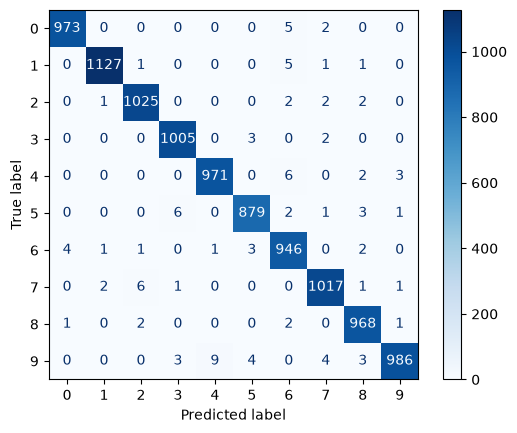

In [36]:
confMatrix = ConfusionMatrixDisplay(matrix).plot(cmap=plt.cm.Blues)
confMatrix.figure_.savefig("../docs/images/lenet_confusion.png", dpi=150)

In [37]:
print(classification_report(y_test, high, digits=4))
print("Macro F1:", f1_score(y_test, high, average="macro"))

              precision    recall  f1-score   support

           0     0.9949    0.9929    0.9939       980
           1     0.9965    0.9930    0.9947      1135
           2     0.9903    0.9932    0.9918      1032
           3     0.9901    0.9950    0.9926      1010
           4     0.9898    0.9888    0.9893       982
           5     0.9888    0.9854    0.9871       892
           6     0.9773    0.9875    0.9823       958
           7     0.9883    0.9893    0.9888      1028
           8     0.9857    0.9938    0.9898       974
           9     0.9940    0.9772    0.9855      1009

    accuracy                         0.9897     10000
   macro avg     0.9896    0.9896    0.9896     10000
weighted avg     0.9897    0.9897    0.9897     10000

Macro F1: 0.9895779528426001
